Imports

In [1]:
import numpy as np
np.random.seed(42)  
import matplotlib.pyplot as plt

Helper function: Generate data 

In [2]:
def generate_data(mean_neg, mean_pos, cov, size=200, split_ratio=0.7):
    # Generate class -1 and 1
    X_neg = np.random.multivariate_normal(mean_neg, cov, size)
    y_neg = -np.ones(size)
    X_pos = np.random.multivariate_normal(mean_pos, cov, size)
    y_pos = np.ones(size)
    
    # Combine and shuffle
    X = np.vstack((X_neg, X_pos))
    y = np.concatenate((y_neg, y_pos))
    indices = np.random.permutation(len(X))
    X, y = X[indices], y[indices]
    
    # 70-30 Split 
    split_idx = int(len(X) * split_ratio)
    return X[:split_idx], X[split_idx:], y[:split_idx], y[split_idx:]

Perceptron class

In [3]:
class Perceptron:
    
    def __init__(self, learning_rate=0.01, epochs=300):
        self.eta = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = 0.0
        self.errors_log = []
        self.convergence_epoch = None

    def fit(self, X, y):
        # Initialize weights and bias 
        self.weights = np.zeros(X.shape[1])
        self.bias = 0.0
        self.errors_log = []
        self.convergence_epoch = None
        
        for epoch in range(1, self.epochs + 1):
            errors = 0
            for i in range(len(X)):
                # Decision rule
                linear_output = np.dot(X[i], self.weights) + self.bias
                prediction = 1 if linear_output >= 0 else -1
                
                # Weight update rule 
                if prediction != y[i]:
                    self.weights += self.eta * y[i] * X[i]
                    self.bias += self.eta * y[i]
                    errors += 1
            
            self.errors_log.append(errors)
            
            # Early stopping
            if errors == 0:
                self.convergence_epoch = epoch
                break
        return self

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return np.where(linear_output >= 0, 1, -1)

    # Accuracy
    def score(self, X, y):
        predictions = self.predict(X)
        return np.mean(predictions == y)

Helper function: Plot db 
$$
w_1 x_1 + w_2 x_2 + b = 0 \;\Rightarrow\; x_2 = -\frac{w_1 x_1 + b}{w_2}
$$

In [4]:
def plot_decision_boundary(model, X, y, title):
    plt.figure(figsize=(9, 4))
    plt.scatter(X[y == -1][:, 0], X[y == -1][:, 1], color='red', alpha=0.5, label='Class -1')
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', alpha=0.5, label='Class 1')
    
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    if model.weights[1] != 0:
        x_vals = np.array([x1_min, x1_max])
        y_vals = -(model.weights[0] * x_vals + model.bias) / model.weights[1]
        plt.plot(x_vals, y_vals, 'k-', lw=2, label='Decision Boundary')
        
    plt.title(title)
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

Execution for Dataset A

Final Weights: [0.0237588  0.02371654]
Final Bias: -0.01

Convergence Epoch: 2
Test Accuracy: 100.00%


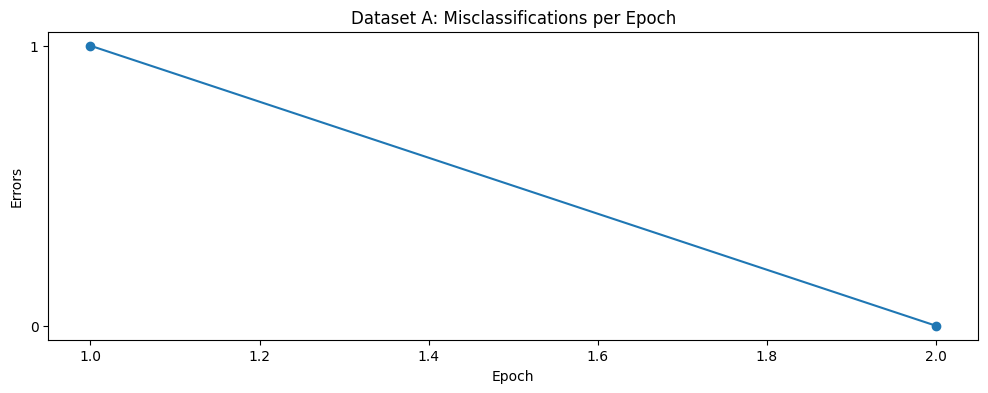

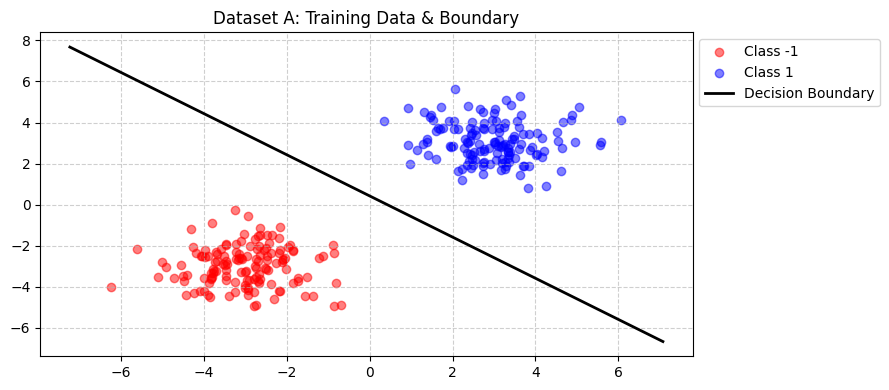

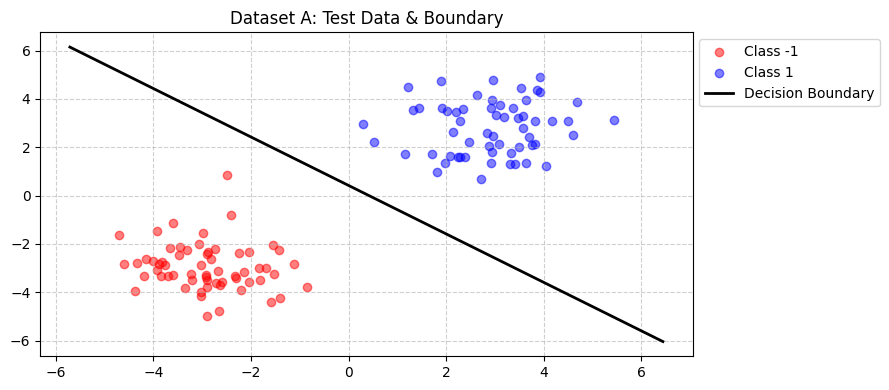

In [5]:
X_train_A, X_test_A, y_train_A, y_test_A = generate_data([-3, -3], [3, 3], np.eye(2))

model_A = Perceptron(learning_rate=0.01, epochs=300)
model_A.fit(X_train_A, y_train_A)

print(f"Final Weights: {model_A.weights}")
print(f"Final Bias: {model_A.bias}")
print()

print(f"Convergence Epoch: {model_A.convergence_epoch if model_A.convergence_epoch else '>300'}")
print(f"Test Accuracy: {model_A.score(X_test_A, y_test_A) * 100:.2f}%")

plt.figure(figsize=(12, 4))
plt.plot(range(1, len(model_A.errors_log) + 1), model_A.errors_log, marker='o')
plt.yticks(range(min(model_A.errors_log), max(model_A.errors_log)+1))
plt.title("Dataset A: Misclassifications per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Errors")
plt.show()

plot_decision_boundary(model_A, X_train_A, y_train_A, "Dataset A: Training Data & Boundary")
plot_decision_boundary(model_A, X_test_A, y_test_A, "Dataset A: Test Data & Boundary")

Execution for Dataset B

Final Weights: [0.03791832 0.04546908]
Final Bias: -0.019999999999999997

Convergence Epoch: >300
Test Accuracy: 99.17%


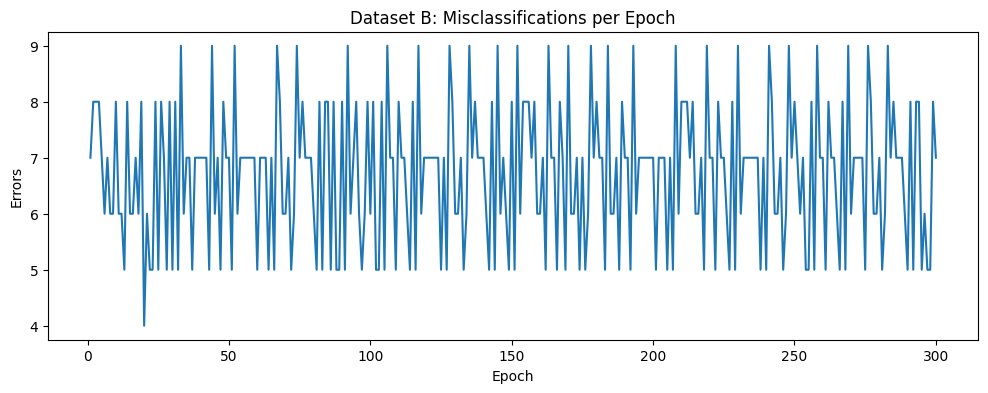

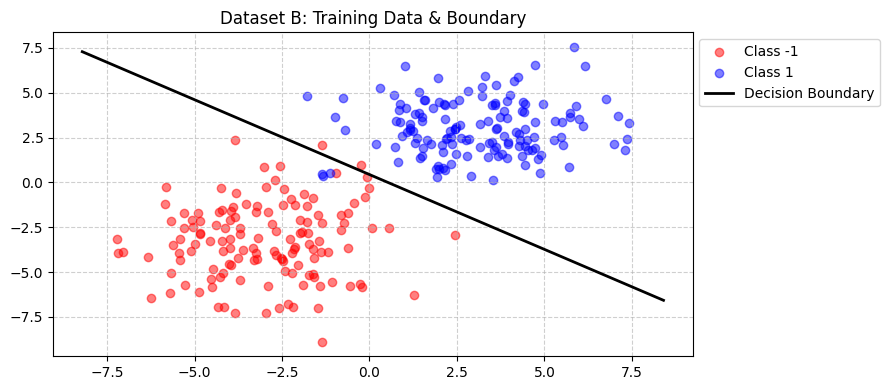

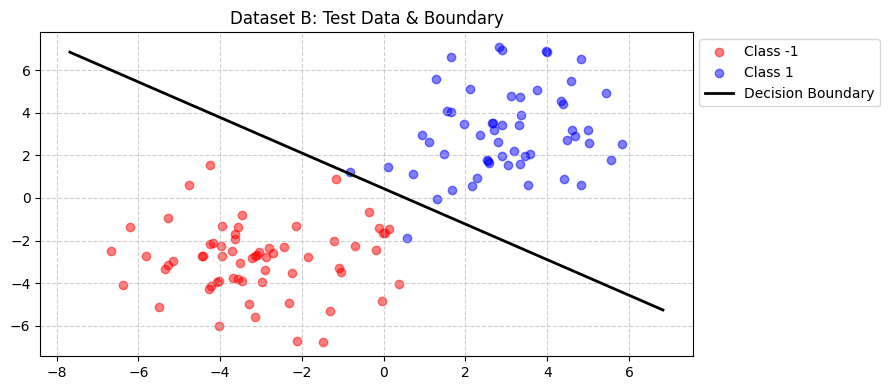

In [6]:
X_train_B, X_test_B, y_train_B, y_test_B = generate_data([-3, -3], [3, 3], 3 * np.eye(2))

model_B = Perceptron(learning_rate=0.01, epochs=300)
model_B.fit(X_train_B, y_train_B)

print(f"Final Weights: {model_B.weights}")
print(f"Final Bias: {model_B.bias}")
print()

print(f"Convergence Epoch: {model_B.convergence_epoch if model_B.convergence_epoch else '>300'}")
print(f"Test Accuracy: {model_B.score(X_test_B, y_test_B) * 100:.2f}%")

plt.figure(figsize=(12, 4))
plt.plot(range(1, len(model_B.errors_log) + 1), model_B.errors_log)
plt.yticks(range(min(model_B.errors_log), max(model_B.errors_log)+1))
plt.title("Dataset B: Misclassifications per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Errors")
plt.show()

plot_decision_boundary(model_B, X_train_B, y_train_B, "Dataset B: Training Data & Boundary")
plot_decision_boundary(model_B, X_test_B, y_test_B, "Dataset B: Test Data & Boundary")

Linear Separability

The convergence of the Perceptron algorithm is fundamentally tied to the existence of a hyperplane $(w, b)$ that satisfies the functional margin condition for all $i$:
$$y_i (w^T x_i + b) \ge \gamma, \quad \text{where } \gamma > 0$$

In [ ]:
def min_margin(model, X, y):
    margins = y * (np.dot(X, model.weights) + model.bias)
    min_gamma = np.min(margins)
    return min_gamma

gamma_A = min_margin(model_A, X_train_A, y_train_A)
print(f"Dataset A Minimum Margin: {gamma_A:.4f}")

gamma_B = min_margin(model_B, X_train_B, y_train_B)
print(f"Dataset B Minimum Margin: {gamma_B:.4f}")

Dataset A Minimum Margin: 0.0601
Dataset B Minimum Margin: -0.0549
